<a href="https://colab.research.google.com/github/lucianarajo-lab/projects/blob/main/Taller_Indivdual_Simulacion_Integral_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de una API de Machine Learning utilizando Teoría de Colas y Gestión de Recursos Computacionales

**Introducción**

Las plataformas de Machine Learning en producción reciben múltiples solicitudes de usuarios que necesitan ser procesadas en tiempos cortos. Cada petición requiere capacidad computacional, como el uso de nodos GPU, y además consume recursos asociados a la infraestructura en la nube.

En este trabajo se desarrolla una simulación de eventos discretos (DES) para representar el funcionamiento de una API de Machine Learning. El modelo combina conceptos de teoría de colas e inventario de recursos, donde las solicitudes representan clientes que llegan al sistema, los nodos GPU representan los servidores disponibles y los créditos de nube representan el inventario necesario para ejecutar predicciones.

La simulación permite analizar el comportamiento del sistema durante 60 minutos, evaluando métricas importantes como el tiempo de espera en cola (Wq), la utilización de los nodos GPU y la cantidad de predicciones fallidas cuando no existen créditos suficientes.

Además, mediante múltiples réplicas se obtiene un análisis estadístico más confiable utilizando intervalos de confianza al 95%, permitiendo evaluar si la infraestructura configurada puede mantener la disponibilidad del servicio.

**Importación de librerías**

Para construir la simulación se utilizan herramientas especializadas.
La librería SimPy permite modelar eventos que ocurren en diferentes momentos del tiempo, como la llegada de solicitudes, el procesamiento de imágenes y la recarga de créditos.

También se utilizan librerías estadísticas para analizar los resultados obtenidos en las diferentes réplicas del experimento.

In [ ]:
!pip install simpy


In [ ]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Fijamos una semilla para reproducibilidad inicial (opcional)
np.random.seed(30)
random.seed(30)

# Configuración de gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)


**1. Configuración de parámetros del sistema**

En esta sección se establecen las condiciones reales de operación de la API.


*   La tasa de llegada (λ) representa la cantidad promedio de solicitudes que ingresan al sistema por minuto.

*   La tasa de servicio (μ) indica la capacidad de procesamiento de cada nodo GPU.

*   El sistema cuenta con cuatro nodos GPU trabajando en paralelo.

Además, se incorpora una política de inventario de créditos donde, al llegar a un nivel mínimo, se genera una solicitud automática de recarga después de un tiempo de espera definido.


In [ ]:
# Parámetros de teoría de colas M/M/c

LAMBDA = 30        # solicitudes por minuto
MU = 10            # imágenes procesadas por minuto
NODOS_GPU = 4      # cantidad de nodos GPU

# Parámetros de recursos computacionales

CREDITOS_INICIALES = 500
PUNTO_REORDEN_s = 50
RECARGA_Q = 400
LEAD_TIME = 2

# Tiempo total de simulación

TIEMPO_SIMULACION = 60

**2. Construcción del modelo de eventos discretos (DES)**

En esta sección se construye el modelo que representa el funcionamiento interno de la API de Machine Learning.

La simulación utiliza eventos discretos porque el sistema cambia únicamente cuando ocurre un evento importante, por ejemplo:

- Una nueva petición llega al sistema.
- Un nodo GPU comienza a procesar una imagen.
- Finaliza una predicción.
- Los créditos computacionales disminuyen.
- Se realiza una recarga de créditos.

La clase creada representa la infraestructura de la API. Los nodos GPU funcionan como servidores en una cola M/M/c, mientras que los créditos cloud se manejan como un inventario que debe mantenerse disponible para evitar fallos en las predicciones.


In [ ]:
class API_MachineLearning:

    def __init__(self, env, nodos_gpu, creditos_ini, punto_reorden, recarga, lead_time):

        self.env = env

        # Recurso que representa los nodos GPU disponibles
        self.nodos_GPU = simpy.Resource(env, capacity=nodos_gpu)

        # Inventario de créditos computacionales
        self.creditos = simpy.Container(
            env,
            init=creditos_ini,
            capacity=10000
        )


        # Parámetros de reposición de créditos
        self.punto_reorden = punto_reorden
        self.recarga = recarga
        self.lead_time = lead_time


        # Control de pedidos pendientes
        self.recarga_pendiente = 0


        # Métricas del sistema

        self.tiempos_espera = []
        self.predicciones_exitosas = 0
        self.predicciones_fallidas = 0


        # Registro del consumo de créditos

        self.registro_creditos = []
        self.registro_tiempo = []



    def solicitar_recarga(self):
        """
        Simula la llegada de nuevos créditos desde la nube.
        """

        self.recarga_pendiente += 1


        # Tiempo variable de llegada de créditos
        tiempo_real = max(
            0.1,
            random.normalvariate(self.lead_time,0.5)
        )


        yield self.env.timeout(tiempo_real)


        # Se agregan los nuevos créditos
        yield self.creditos.put(self.recarga)


        self.recarga_pendiente -= 1




    def controlar_creditos(self):
        """
        Verifica continuamente el nivel de créditos disponibles.
        Cuando llegan al punto mínimo se solicita una recarga.
        """

        while True:

            self.registro_creditos.append(
                self.creditos.level
            )

            self.registro_tiempo.append(
                self.env.now
            )


            # Política (s,Q)
            if (
                self.creditos.level <= self.punto_reorden
                and self.recarga_pendiente == 0
            ):

                self.env.process(
                    self.solicitar_recarga()
                )


            # Revisión cada minuto

            yield self.env.timeout(1)

**Simulación de una petición de usuario**

Cada solicitud enviada a la API representa una petición de predicción realizada por un usuario.

Cuando una petición llega, debe esperar hasta que exista disponibilidad en alguno de los nodos GPU. Este tiempo representa la latencia en cola del sistema (Wq).

Después de obtener un nodo GPU, se realiza el procesamiento de la imagen y se consumen créditos computacionales. Si los créditos disponibles son suficientes, la predicción se completa correctamente; en caso contrario, la solicitud falla por falta de recursos.

In [ ]:
def peticion_usuario(env, nombre, api, mu):

    # Momento en que llega la petición
    llegada = env.now


    # Solicita un nodo GPU disponible
    with api.nodos_GPU.request() as solicitud:

        yield solicitud


        # Cálculo del tiempo de espera en cola Wq
        tiempo_espera = env.now - llegada

        api.tiempos_espera.append(
            tiempo_espera
        )


        # Tiempo de procesamiento de la imagen
        tiempo_procesamiento = random.expovariate(mu)


        yield env.timeout(
            tiempo_procesamiento
        )



        # Consumo de créditos por predicción

        if api.creditos.level >= 1:

            yield api.creditos.get(1)

            api.predicciones_exitosas += 1


        else:

            api.predicciones_fallidas += 1

**Generador de solicitudes de usuarios**

Las peticiones llegan siguiendo un proceso aleatorio de Poisson.

La tasa de llegada definida por λ = 30 solicitudes por minuto indica que la API recibe aproximadamente 30 peticiones cada minuto.

Cada nueva llegada genera un proceso independiente dentro de la simulación, permitiendo observar cómo se comporta la cola cuando múltiples usuarios solicitan predicciones al mismo tiempo.

In [ ]:
def generador_peticion(env, api, lam, mu):

    contador = 0


    while True:

        # Tiempo entre llegadas
        yield env.timeout(
            random.expovariate(lam)
        )


        contador += 1


        env.process(
            peticion_usuario(
                env,
                f"Peticion {contador}",
                api,
                mu
            )
        )

**3. Ejecución y Visualización Inicial**

En esta etapa se ejecuta una primera corrida del modelo durante 60 minutos.

El objetivo es observar cómo se comporta la infraestructura de la API cuando recibe solicitudes de usuarios de manera continua.

Durante la simulación se registra el nivel de créditos disponibles, permitiendo analizar si la política de reposición (s,Q) mantiene suficientes recursos para evitar interrupciones en el servicio.

Esta primera ejecución permite validar que los eventos de llegada, procesamiento y consumo de créditos funcionan correctamente antes de realizar el análisis estadístico con múltiples réplicas.


In [ ]:
def ejecutar_simulacion_visual(tiempo_sim):

    env = simpy.Environment()


    api = API_MachineLearning(
        env,
        NODOS_GPU,
        CREDITOS_INICIALES,
        PUNTO_REORDEN_s,
        RECARGA_Q,
        LEAD_TIME
    )


    # Activación de procesos

    env.process(
        generador_peticion(
            env,
            api,
            LAMBDA,
            MU
        )
    )


    env.process(
        api.controlar_creditos()
    )


    # Ejecutar simulación

    env.run(
        until=tiempo_sim
    )


    # Gráfico de créditos

    plt.figure(figsize=(12,5))


    plt.step(
        api.registro_tiempo,
        api.registro_creditos,
        where="post",
        label="Créditos disponibles"
    )


    plt.axhline(
        y=PUNTO_REORDEN_s,
        linestyle="--",
        label="Punto de reorden"
    )


    plt.title(
        "Consumo y reposición de créditos de la API ML"
    )


    plt.xlabel(
        "Tiempo (minutos)"
    )


    plt.ylabel(
        "Créditos Cloud"
    )


    plt.legend()

    plt.show()



    # Resultados

    wq_promedio = (
        np.mean(api.tiempos_espera)
        * 60
    )


    print(
        "--- RESULTADOS DE UNA CORRIDA ---"
    )

    print(
        f"Predicciones exitosas: {api.predicciones_exitosas}"
    )

    print(
        f"Predicciones fallidas: {api.predicciones_fallidas}"
    )

    print(
        f"Tiempo promedio de espera Wq: {wq_promedio:.2f} segundos"
    )

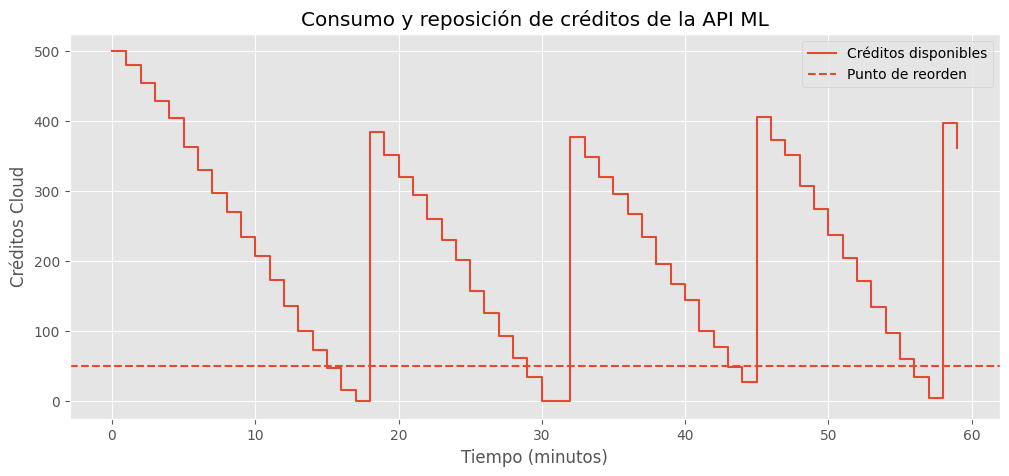

--- RESULTADOS DE UNA CORRIDA ---
Predicciones exitosas: 1761
Predicciones fallidas: 62
Tiempo promedio de espera Wq: 3.56 segundos


In [ ]:
ejecutar_simulacion_visual(
    TIEMPO_SIMULACION
)

**4. Evaluación estadística del sistema mediante múltiples réplicas**

Debido a que la simulación contiene elementos aleatorios, como la llegada de solicitudes y los tiempos de procesamiento, una sola ejecución no representa completamente el comportamiento del sistema.

Por esta razón se realizan 30 réplicas independientes del escenario de 60 minutos.

Con los resultados obtenidos se calcula:

- El intervalo de confianza del 95% del tiempo de espera en cola (Wq).
- El promedio de predicciones fallidas por falta de créditos.
- La utilización teórica de los nodos GPU mediante la fórmula:

ρ= λ / c × μ
	​

donde:

- λ representa la tasa de llegada de solicitudes.
- μ representa la capacidad de procesamiento.
- c representa la cantidad de nodos GPU.

Esta evaluación permite determinar si el sistema tiene suficiente capacidad de procesamiento y si la política de créditos mantiene la disponibilidad del servicio.

In [ ]:
def calcular_intervalo_confianza(datos, confianza=0.95):
    n = len(datos)
    media = np.mean(datos)
    error = st.sem(datos)
    margen = (
        error *
        st.t.ppf(
            (1 + confianza) / 2,
            n - 1
        )
    )
    return (
        media,
        media - margen,
        media + margen
    )

**Ejecución de 30 réplicas del escenario**

Cada réplica representa una posible ejecución real de la API bajo las mismas condiciones operativas.

Al repetir el experimento se reducen los efectos de la aleatoriedad y se obtiene una estimación más confiable del desempeño del sistema.

In [ ]:
def evaluacion_operacional(replicas, tiempo_sim):
    resultados_wq = []
    resultados_fallos = []

    for r in range(replicas):
        env = simpy.Environment()
        api = API_MachineLearning(
            env,
            NODOS_GPU,
            CREDITOS_INICIALES,
            PUNTO_REORDEN_s,
            RECARGA_Q,
            LEAD_TIME
        )
        env.process(
            generador_peticion(
                env,
                api,
                LAMBDA,
                MU
            )
        )
        env.process(
            api.controlar_creditos()
        )
        env.run(
            until=tiempo_sim
        )

        # Tiempo promedio de espera
        wq = (
            np.mean(api.tiempos_espera)
            * 60
        )

        resultados_wq.append(wq)

        # Fallos por falta de créditos
        resultados_fallos.append(
            api.predicciones_fallidas
        )

    # Intervalo de confianza Wq
    media_wq, limite_inf, limite_sup = (
        calcular_intervalo_confianza(
            resultados_wq
        )
    )
    promedio_fallos = np.mean(
        resultados_fallos
    )

    # Utilización teórica GPU
    rho = (
        LAMBDA /
        (NODOS_GPU * MU)
    )

    print(
        "------ RESULTADOS OPERACIONALES API ML ------"
    )
    print(
        f"Intervalo confianza 95% Wq: "
        f"[{limite_inf:.2f}, {limite_sup:.2f}] segundos"
    )

    print(
        f"Promedio predicciones fallidas: "
        f"{promedio_fallos:.2f}"
    )

    print(
        f"Utilización teórica GPU (ρ): "
        f"{rho:.2%}"
    )

In [ ]:
evaluacion_operacional(
    replicas=30,
    tiempo_sim=TIEMPO_SIMULACION
)

------ RESULTADOS OPERACIONALES API ML ------
Intervalo confianza 95% Wq: [2.70, 3.53] segundos
Promedio predicciones fallidas: 92.77
Utilización teórica GPU (ρ): 75.00%


**Análisis del comportamiento del sistema**

Después de ejecutar la simulación se observa que la utilización de los nodos GPU puede mantenerse estable sin llegar al límite de capacidad. Sin embargo, pueden existir predicciones fallidas debido a que el procesamiento y la disponibilidad de créditos son recursos independientes.

La utilización GPU mide únicamente la capacidad de procesamiento disponible, pero no representa la cantidad de créditos necesarios para ejecutar nuevas predicciones.

Por esta razón, aunque existan nodos GPU disponibles, una solicitud puede fallar si los créditos de nube llegan a cero antes de que finalice el tiempo de recarga.

El problema no se encuentra en la infraestructura de hardware, sino en la política de gestión de recursos computacionales. Por ello es necesario ajustar el punto de reorden (s) para solicitar créditos con suficiente anticipación.

**Búsqueda del punto de reorden óptimo**

Para garantizar que no existan predicciones fallidas se evalúan diferentes valores del punto de reorden (s).

El objetivo es encontrar el menor valor de créditos que permita activar la recarga antes de que el sistema llegue a quedarse sin recursos.

El valor encontrado será utilizado como nueva política de inventario para asegurar la continuidad del servicio.

In [ ]:
def probar_punto_reorden(valor_s):
    env = simpy.Environment()
    api = API_MachineLearning(
        env,
        NODOS_GPU,
        CREDITOS_INICIALES,
        valor_s,
        RECARGA_Q,
        LEAD_TIME
    )

    env.process(
        generador_peticion(
            env,
            api,
            LAMBDA,
            MU
        )
    )

    env.process(
        api.controlar_creditos()
    )

    env.run(
        until=TIEMPO_SIMULACION
    )
    return api.predicciones_fallidas

# Buscar valor adecuado

for s in range(50,401,10):

    fallos = probar_punto_reorden(s)


    print(
        f"Punto de reorden {s}: {fallos} fallos"
    )

Punto de reorden 50: 108 fallos
Punto de reorden 60: 27 fallos
Punto de reorden 70: 97 fallos
Punto de reorden 80: 12 fallos
Punto de reorden 90: 13 fallos
Punto de reorden 100: 0 fallos
Punto de reorden 110: 0 fallos
Punto de reorden 120: 0 fallos
Punto de reorden 130: 0 fallos
Punto de reorden 140: 0 fallos
Punto de reorden 150: 0 fallos
Punto de reorden 160: 0 fallos
Punto de reorden 170: 0 fallos
Punto de reorden 180: 0 fallos
Punto de reorden 190: 0 fallos
Punto de reorden 200: 0 fallos
Punto de reorden 210: 0 fallos
Punto de reorden 220: 0 fallos
Punto de reorden 230: 0 fallos
Punto de reorden 240: 0 fallos
Punto de reorden 250: 0 fallos
Punto de reorden 260: 0 fallos
Punto de reorden 270: 0 fallos
Punto de reorden 280: 0 fallos
Punto de reorden 290: 0 fallos
Punto de reorden 300: 0 fallos
Punto de reorden 310: 0 fallos
Punto de reorden 320: 0 fallos
Punto de reorden 330: 0 fallos
Punto de reorden 340: 0 fallos
Punto de reorden 350: 0 fallos
Punto de reorden 360: 0 fallos
Punto d

**Justificación del nuevo punto de reorden**
El nuevo valor del punto de reorden representa el nivel mínimo de créditos donde la API debe iniciar automáticamente una reposición.

Al aumentar este valor, el sistema tiene mayor anticipación para solicitar nuevos créditos antes de agotarlos durante el tiempo de espera de la recarga (Lead Time).

La simulación permite seleccionar el valor mínimo de s que mantiene las predicciones fallidas en cero, logrando un equilibrio entre disponibilidad del servicio y uso eficiente de recursos.